# HW1: Pathology QA - Llama-3.2-1B with Few-Shot CoT
本筆記本使用 `unsloth/Llama-3.2-1B-Instruct` 進行微調。
推論階段採用 **Few-Shot Chain-of-Thought (CoT)** 策略，引導模型先進行病理學推理，再給出最終答案。
最後會生成符合 Kaggle 格式的 `submission.csv`。

### [Sec 1] setup enviroment

In [ ]:
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps xformers peft accelerate bitsandbytes
!pip install pandas matplotlib seaborn scikit-learn tqdm
!pip install "trl==0.19.1"


from collections import Counter
import os
import random
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import transformers
from datasets import Dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from trl import DataCollatorForCompletionOnlyLM, SFTTrainer
from unsloth import FastLanguageModel
from transformers import TrainingArguments

# Fix TRL/Transformers version mismatch on Colab/runtime
!pip install -U -q "transformers==5.3.0" "trl!=0.19.0,>=0.18.2,<=0.24.0"


  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-vvdgse95/unsloth_98e86cace1b64b288248ffed5d1b85ef
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-vvdgse95/unsloth_98e86cace1b64b288248ffed5d1b85ef
  Resolved https://github.com/unslothai/unsloth.git to commit 937da02f6c64eb4ecd19ba4fba0b12838e6a9bde
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 144.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.9/402.9 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 137.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 41.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.2/376.2 kB 9.2 MB/s eta 0:00:00:00:01
  Attempting uninstall: trl
    Found existing installation: trl 0.24.0
    Uninstalling trl-0.24.0:
      Successfully uninstalled trl-0.24.0


RuntimeError: Failed to import trl.trainer.utils because of the following error (look up to see its traceback):
cannot import name 'is_fouroversix_available' from 'transformers.utils.import_utils' (/usr/local/lib/python3.12/dist-packages/transformers/utils/import_utils.py)

### [Sec 2] 設定路徑與模型

In [6]:
# ==========================================
# 1. 路徑設定 (請依據你的 Colab 掛載環境確認)
# ==========================================

dataset_path = "./dataset/dataset.csv"
benchmark_path = "./dataset/benchmark.csv"
output_model_path = "./saved_models/lora_model"
submission_path = "./submission.csv"

# ==========================================
# 2. 載入模型與 LoRA 設定
# ==========================================
max_seq_length = 1024
dtype = None # 自動偵測
load_in_4bit = True # 4-bit 量化節省 VRAM

print("正在載入 Llama-3.2-1B 模型...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-1B-Instruct",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 64,
    lora_alpha = 128,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_dropout = 0.07,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    modules_to_save = ["embed_tokens", "lm_head"],
)
print("模型與 LoRA 初始化完成！")

正在載入 Llama-3.2-1B 模型...


NameError: name 'FastLanguageModel' is not defined

### [Sec 2.5] Prompt

In [27]:
prompt_template = """System: You are an elite, board-certified expert in Medical Pathology. Your task is to evaluate clinical and pathological multiple-choice questions with absolute medical accuracy.

### strict_rules:
1. Analyze the question and the four options carefully.
2. Output ONLY the single correct letter (A, B, C, or D).
3. DO NOT output any explanations, rationale, punctuation, or preamble.
4. Failure to adhere to these format constraints will result in system failure.
5. Think step-by-step through the pathological mechanisms before answering.

---
### demonstration_examples:

[Question]:
RBC contains?
[Options]:
A. Iron
B. Folic acid
C. Vitamin C
D. Biotin
[Answer]:
A

[Question]:
Fibrosis is due to -
[Options]:
A. TNF -α
B. TGF-β
C. IL-7
D. IL-10
[Answer]:
B

[Question]:
Ability of stem cells to cross barrier of differentiation to transform into a cell of another lineage expressing the molecular characteristics of different cell type with the ability to perform the function of the new cell type is referred as:
[Options]:
A. De differentiation
B. Re differentiation
C. Trans-differentiation
D. Sub differentiation
[Answer]:
C

[Question]:
Severe hypovolemic shock occurs when blood volume less is -
[Options]:
A. > 10 %
B. > 20 %
C. > 30 %
D. > 40%
[Answer]:
D

---
### current_task:
[Question]:
{question}
[Options]:
A. {opa}
B. {opb}
C. {opc}
D. {opd}
[Answer]:
{ans}
"""

In [28]:
inference_prompt_template = """System: You are an elite, board-certified expert in Medical Pathology. Your task is to evaluate clinical and pathological multiple-choice questions with absolute medical accuracy.

### strict_rules:
1. Analyze the question and the four options carefully.
2. Output ONLY the single correct letter (A, B, C, or D).
3. DO NOT output any explanations, rationale, punctuation, or preamble.
4. Failure to adhere to these format constraints will result in system failure.
5. Think step-by-step through the pathological mechanisms before answering.

---
### demonstration_examples:

[Question]:
RBC contains?
[Options]:
A. Iron
B. Folic acid
C. Vitamin C
D. Biotin
[Answer]:
A

[Question]:
Fibrosis is due to -
[Options]:
A. TNF -α
B. TGF-β
C. IL-7
D. IL-10
[Answer]:
B

[Question]:
Ability of stem cells to cross barrier of differentiation to transform into a cell of another lineage expressing the molecular characteristics of different cell type with the ability to perform the function of the new cell type is referred as:
[Options]:
A. De differentiation
B. Re differentiation
C. Trans-differentiation
D. Sub differentiation
[Answer]:
C

[Question]:
Severe hypovolemic shock occurs when blood volume less is -
[Options]:
A. > 10 %
B. > 20 %
C. > 30 %
D. > 40%
[Answer]:
D

---
### current_task:
[Question]:
{question}
[Options]:
A. {opa}
B. {opb}
C. {opc}
D. {opd}
[Answer]:
"""

### [Sec 3] Data

In [37]:
# [區塊 3] 資料擴增與 Prompt 格式化 (Training)

print(f"📂 正在讀取資料集: {dataset_path}")
df = pd.read_csv(dataset_path)

# 將答案 0, 1, 2, 3 映射為 A, B, C, D
num_to_letter = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}
df['ans_letter'] = df['ans'].map(num_to_letter)

# 1. 🌟 關鍵：先切割資料集 (80% Train, 20% Val)，保護驗證集不被污染
train_df, val_df = train_test_split(df, test_size=0.15, random_state=42)
val_df, test_df = train_test_split(val_df, test_size=0.5, random_state=42)
print(f"原始訓練集數量: {len(train_df)}, 驗證集數量: {len(val_df)},   測試集數量：{len(test_df)}")


def augment_mcq_data(input_df):
    new_rows = []
    num_to_letter = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}

    for _, row in input_df.iterrows():
        options = [row['opa'], row['opb'], row['opc'], row['opd']]
        correct_text = options[row['ans']]

        # 抓出所有的「錯誤選項 (干擾項)」
        distractors = [opt for opt in options if opt != correct_text]

        # 強制迴圈 4 次，讓這題的正確答案分別去當 A, B, C, D (即 index 0, 1, 2, 3)
        for target_ans_idx in range(4):
            new_options = ["", "", "", ""] # Initialize with empty strings
            new_options[target_ans_idx] = correct_text

            current_distractors = distractors.copy()
            random.shuffle(current_distractors)

            # Handle cases where there might be fewer than 3 unique distractors
            if not current_distractors: # If there are no distractors at all (e.g., all options are the same as correct_text)
                # This case is unlikely for MCQs but defensively handled
                # Fill with placeholders or the correct answer itself as a placeholder
                fill_options = ['Placeholder1', 'Placeholder2', 'Placeholder3']
            else:
                # Cycle through available distractors if there aren't enough unique ones
                fill_options = []
                for k in range(3): # Need 3 items to fill incorrect slots
                    fill_options.append(current_distractors[k % len(current_distractors)])

            distractor_counter = 0
            for i in range(4):
                if i != target_ans_idx:
                    new_options[i] = fill_options[distractor_counter]
                    distractor_counter += 1

            # 建立新的一筆資料
            new_row = row.copy()
            new_row['opa'] = new_options[0]
            new_row['opb'] = new_options[1]
            new_row['opc'] = new_options[2]
            new_row['opd'] = new_options[3]
            new_row['ans'] = target_ans_idx
            new_row['ans_letter'] = num_to_letter[target_ans_idx]

            new_rows.append(new_row)

    return pd.DataFrame(new_rows)

# 3. 只對訓練集進行資料擴增
# train_df = augment_mcq_data(train_df)

# 洗牌打亂順序，避免模型學到規律
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"擴增後 -> 最終訓練集數量: {len(train_df)}")


def format_data(row):
    return prompt_template.format(
        question=row['question'],
        opa=row['opa'],
        opb=row['opb'],
        opc=row['opc'],
        opd=row['opd'],
        ans=row['ans_letter']
    )

# 5. 套用 Prompt 格式化
tqdm.pandas(desc="Formatting Train Prompts")
train_df['formatted_prompt'] = train_df.progress_apply(format_data, axis=1)

tqdm.pandas(desc="Formatting Val Prompts")
val_df['formatted_prompt'] = val_df.progress_apply(format_data, axis=1)

tqdm.pandas(desc="Formatting Test Prompts")
test_df['formatted_prompt'] = test_df.progress_apply(format_data, axis=1)

# 6. 轉換為 Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

def map_prompts(batch):
    return {"text": batch["formatted_prompt"]}

train_dataset = train_dataset.map(map_prompts, batched=True)
val_dataset = val_dataset.map(map_prompts, batched=True)
test_dataset = test_dataset.map(map_prompts, batched=True)

print(f"✅ 資料處理完畢！準備進入訓練階段。")

📂 正在讀取資料集: /content/drive/MyDrive/GAI/hw-1-question-answering/dataset.csv
原始訓練集數量: 7650, 驗證集數量: 675,   測試集數量：675
擴增後 -> 最終訓練集數量: 7650


Formatting Train Prompts:   0%|          | 0/7650 [00:00<?, ?it/s]

Formatting Val Prompts:   0%|          | 0/675 [00:00<?, ?it/s]

Formatting Test Prompts:   0%|          | 0/675 [00:00<?, ?it/s]

Map:   0%|          | 0/7650 [00:00<?, ? examples/s]

Map:   0%|          | 0/675 [00:00<?, ? examples/s]

Map:   0%|          | 0/675 [00:00<?, ? examples/s]

✅ 資料處理完畢！準備進入訓練階段。


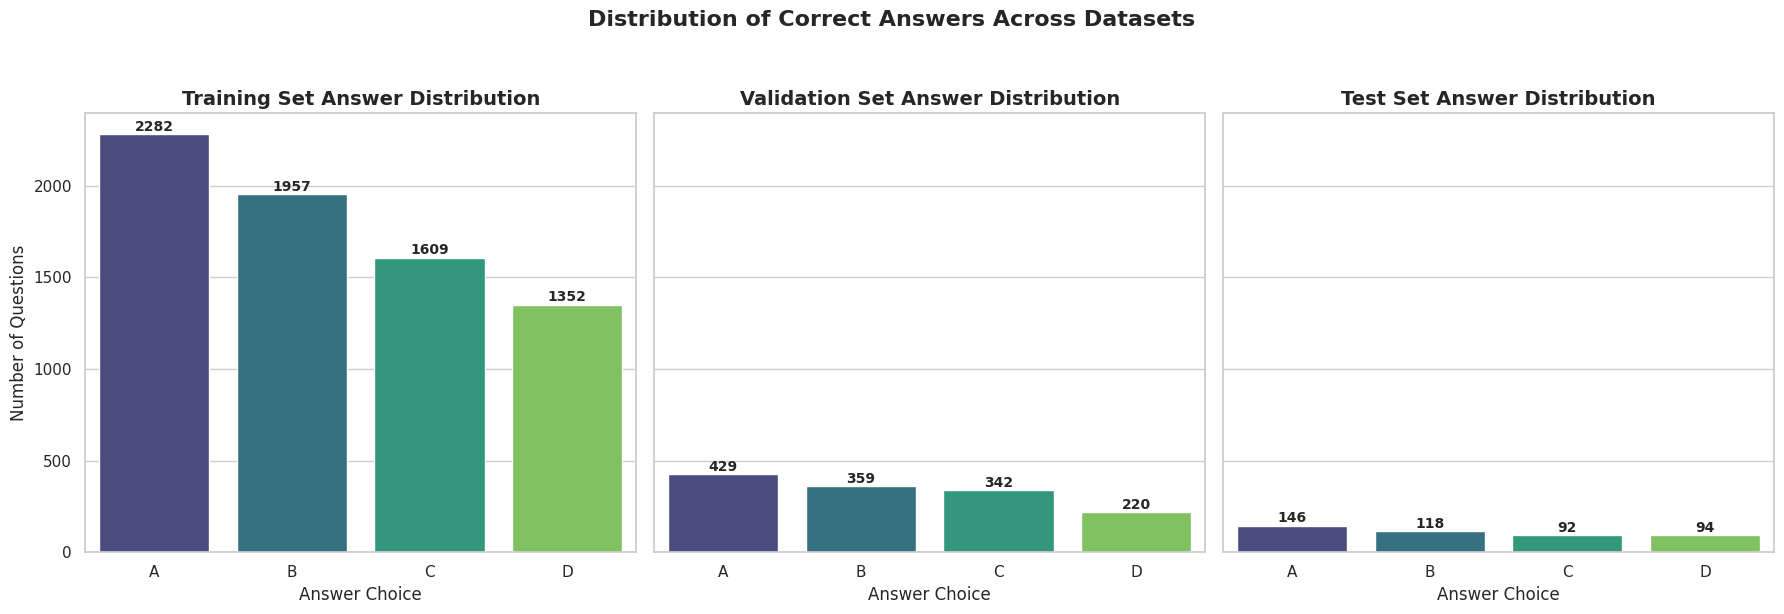

In [30]:
sns.set_theme(style="whitegrid")

# 計算各資料集的答案分佈
train_ans_counts = train_df['ans_letter'].value_counts().reindex(['A', 'B', 'C', 'D'], fill_value=0)
val_ans_counts = val_df['ans_letter'].value_counts().reindex(['A', 'B', 'C', 'D'], fill_value=0)
test_ans_counts = test_df['ans_letter'].value_counts().reindex(['A', 'B', 'C', 'D'], fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# 訓練集分佈圖
sns.barplot(x=train_ans_counts.index, y=train_ans_counts.values, palette='viridis', hue=train_ans_counts.index, legend=False, ax=axes[0])
axes[0].set_title('Training Set Answer Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Answer Choice', fontsize=12)
axes[0].set_ylabel('Number of Questions', fontsize=12)
for index, value in enumerate(train_ans_counts.values):
    axes[0].text(index, value + 0.5, str(value), ha='center', va='bottom', fontsize=10, fontweight='bold')

# 驗證集分佈圖
sns.barplot(x=val_ans_counts.index, y=val_ans_counts.values, palette='viridis', hue=val_ans_counts.index, legend=False, ax=axes[1])
axes[1].set_title('Validation Set Answer Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Answer Choice', fontsize=12)
axes[1].set_ylabel('') # 共享 Y 軸，所以不需要重複標籤
for index, value in enumerate(val_ans_counts.values):
    axes[1].text(index, value + 0.5, str(value), ha='center', va='bottom', fontsize=10, fontweight='bold')

# 測試集分佈圖
sns.barplot(x=test_ans_counts.index, y=test_ans_counts.values, palette='viridis', hue=test_ans_counts.index, legend=False, ax=axes[2])
axes[2].set_title('Test Set Answer Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Answer Choice', fontsize=12)
axes[2].set_ylabel('') # 共享 Y 軸，所以不需要重複標籤
for index, value in enumerate(test_ans_counts.values):
    axes[2].text(index, value + 0.5, str(value), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Distribution of Correct Answers Across Datasets', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # 調整佈局以容納主標題
plt.show()

### [Sec 4] Training

In [ ]:
# 告訴模型，只有出現在 "[Answer]:\n" 之後的字，才需要計算誤差 (Loss)
# 注意：這裡的字串必須跟你 prompt_template 裡面答案前面的格式一模一樣！
response_template = "[Answer]:\n"
collator = DataCollatorForCompletionOnlyLM(response_template=response_template, tokenizer=tokenizer)

# =================================================================
# 訓練參數設定
# =================================================================
training_args = TrainingArguments(
    output_dir = os.path("logs"),
    per_device_train_batch_size = 4,
    gradient_accumulation_steps = 16,
    warmup_steps = 20,
    num_train_epochs = 2,
    learning_rate = 3e-5,
    max_grad_norm = 0.3,           # 梯度裁剪，防止 Loss 突然暴衝
    fp16 = not torch.cuda.is_bf16_supported(),
    bf16 = torch.cuda.is_bf16_supported(),
    logging_steps = 5,
    eval_strategy = "steps",
    eval_steps = 50,
    optim = "adamw_8bit",
    weight_decay = 0.05,
    lr_scheduler_type = "cosine",
    seed = 3707,
)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset = val_dataset,
    dataset_text_field = "text",
    max_seq_length = 1024,
    dataset_num_proc = 2,
    packing = False,
    args = training_args,
    data_collator = collator,
    neftune_noise_alpha = 5,  #抗過擬合
)

print("🚀 開始微調模型...")
trainer_stats = trainer.train()

# 儲存 LoRA 模型權重
model.save_pretrained(output_model_path)
tokenizer.save_pretrained(output_model_path)
print(f"✅ 模型已儲存至: {output_model_path}")

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/7200 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/1350 [00:00<?, ? examples/s]

🚀 開始微調模型...
{'loss': '2.927', 'grad_norm': '88.21', 'learning_rate': '6e-06', 'epoch': '0.04444'}
{'loss': '1.532', 'grad_norm': '23.68', 'learning_rate': '1.35e-05', 'epoch': '0.08889'}
{'loss': '0.5301', 'grad_norm': '9.235', 'learning_rate': '2.1e-05', 'epoch': '0.1333'}
{'loss': '0.5512', 'grad_norm': '7.616', 'learning_rate': '2.85e-05', 'epoch': '0.1778'}
{'loss': '0.4772', 'grad_norm': '6.309', 'learning_rate': '2.997e-05', 'epoch': '0.2222'}
{'loss': '0.4903', 'grad_norm': '6.925', 'learning_rate': '2.986e-05', 'epoch': '0.2667'}
{'loss': '0.4571', 'grad_norm': '6.297', 'learning_rate': '2.966e-05', 'epoch': '0.3111'}
{'loss': '0.4661', 'grad_norm': '7.206', 'learning_rate': '2.937e-05', 'epoch': '0.3556'}
{'loss': '0.4507', 'grad_norm': '8.306', 'learning_rate': '2.901e-05', 'epoch': '0.4'}
{'loss': '0.4217', 'grad_norm': '4.678', 'learning_rate': '2.856e-05', 'epoch': '0.4444'}


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

{'eval_loss': '0.4376', 'eval_runtime': '32.56', 'eval_samples_per_second': '41.46', 'eval_steps_per_second': '10.38', 'epoch': '0.4444'}
{'loss': '0.4271', 'grad_norm': '8.864', 'learning_rate': '2.803e-05', 'epoch': '0.4889'}
{'loss': '0.4264', 'grad_norm': '8.116', 'learning_rate': '2.742e-05', 'epoch': '0.5333'}
{'loss': '0.4307', 'grad_norm': '6.856', 'learning_rate': '2.675e-05', 'epoch': '0.5778'}
{'loss': '0.4512', 'grad_norm': '8.134', 'learning_rate': '2.6e-05', 'epoch': '0.6222'}
{'loss': '0.3968', 'grad_norm': '6.763', 'learning_rate': '2.519e-05', 'epoch': '0.6667'}
{'loss': '0.4456', 'grad_norm': '8.73', 'learning_rate': '2.433e-05', 'epoch': '0.7111'}
{'loss': '0.411', 'grad_norm': '6.999', 'learning_rate': '2.34e-05', 'epoch': '0.7556'}
{'loss': '0.4305', 'grad_norm': '6.89', 'learning_rate': '2.243e-05', 'epoch': '0.8'}
{'loss': '0.4057', 'grad_norm': '7.97', 'learning_rate': '2.142e-05', 'epoch': '0.8444'}
{'loss': '0.4019', 'grad_norm': '8.123', 'learning_rate': '2.0

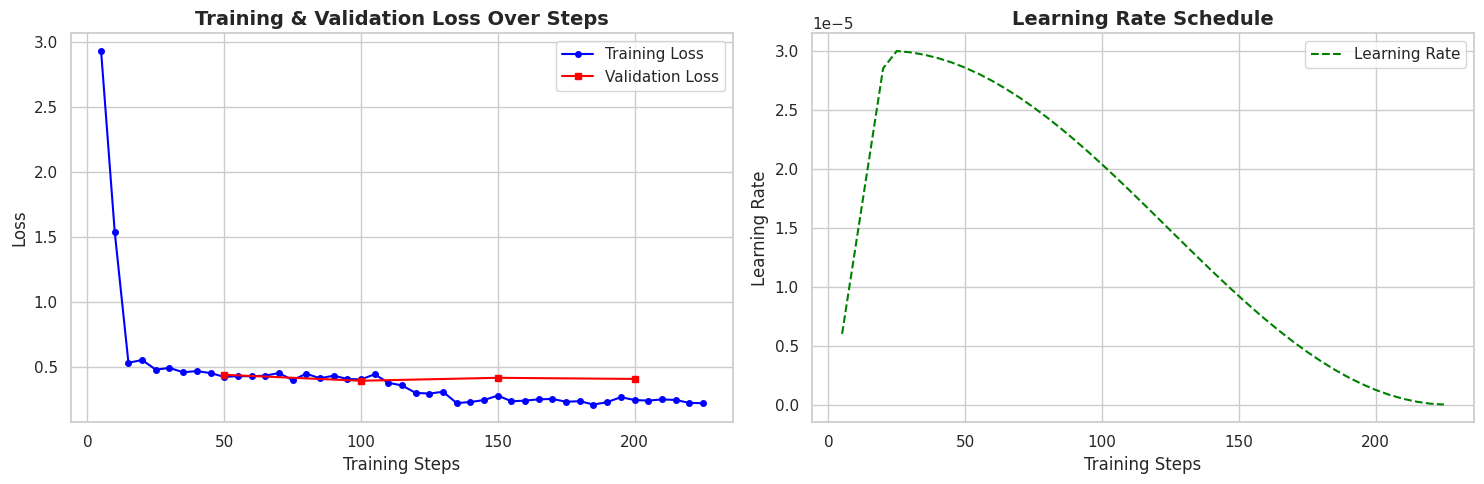

In [32]:
# 設置繪圖風格
sns.set_theme(style="whitegrid")

# 從 Trainer 中提取訓練日誌
log_history = trainer.state.log_history

train_steps, train_loss = [], []
eval_steps, eval_loss = [], []
lr_steps, lr_values = [], []

for log in log_history:
    if "loss" in log and "step" in log:
        train_steps.append(log["step"])
        train_loss.append(log["loss"])
        lr_steps.append(log["step"])
        lr_values.append(log["learning_rate"])
    elif "eval_loss" in log and "step" in log:
        eval_steps.append(log["step"])
        eval_loss.append(log["eval_loss"])

# 建立 1x2 的畫布
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 圖 1: Loss 曲線
axes[0].plot(train_steps, train_loss, label="Training Loss", color="blue", marker="o", markersize=4)
if eval_loss:
    axes[0].plot(eval_steps, eval_loss, label="Validation Loss", color="red", marker="s", markersize=5)
axes[0].set_title("Training & Validation Loss Over Steps", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Training Steps", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].legend()

# 圖 2: Learning Rate 曲線
axes[1].plot(lr_steps, lr_values, label="Learning Rate", color="green", linestyle="--")
axes[1].set_title("Learning Rate Schedule", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Training Steps", fontsize=12)
axes[1].set_ylabel("Learning Rate", fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

In [33]:
# import torch
# torch.cuda.empty_cache()

### [Sec 5] Validation

In [34]:
# 🌟 [修改 2] 把 transformers 的警告層級調高，避免碎碎念打斷進度條
transformers.logging.set_verbosity_error()

# 開啟 Unsloth 的推論加速模式
FastLanguageModel.for_inference(model)

true_labels = []
pred_labels = []

print("🚀 開始進行 Validation 推論")

# 遍歷驗證集
for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Evaluating (Test)"):
    # 填入題目與選項
    prompt = inference_prompt_template.format(
        question=row['question'],
        opa=row['opa'],
        opb=row['opb'],
        opc=row['opc'],
        opd=row['opd']
    )

    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

    # 生成答案
    # 🌟 因為只要模型講一個字母 A, B, C 或 D，把 max_new_tokens 設為 5 就足夠了
    outputs = model.generate(
        **inputs,
        max_new_tokens=5,
        use_cache=False, # Changed to False to prevent RuntimeError
        pad_token_id=tokenizer.eos_token_id
    )

    # 🌟 關鍵技巧：因為 Prompt 裡面已經有 Example 1 & 2 的答案了，
    # 為了避免 Regex 抓到上面的範例，我們「只解碼模型最新生成的那幾個 Token」
    input_length = inputs["input_ids"].shape[1]
    generated_tokens = outputs[0][input_length:]
    output_text = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()

    # 用正規表達式尋找模型輸出的第一個 A, B, C, 或 D
    # print(f"output: {output_text}")
    match = re.search(r'([ABCD])', output_text.upper())

    if match:
        pred = match.group(1)
    else:
        # 預防模型崩潰沒有輸出合法字母的備案
        pred = 'C'
        print("not match, change ans to C")

    pred_labels.append(pred)
    true_labels.append(row['ans_letter'].upper())
    # print(f"pred: {pred} / ans: {row['ans_letter'].upper()}")

# 計算最終準確率
acc = accuracy_score(true_labels, pred_labels)
print(f"\n✅ Validation Accuracy: {acc*100:.2f}%")

🚀 開始進行 Validation 推論


Evaluating (Test):   0%|          | 0/450 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)



✅ Validation Accuracy: 71.11%


📊 Validation Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

           A       0.73      0.79      0.76       146
           B       0.71      0.71      0.71       118
           C       0.68      0.66      0.67        92
           D       0.71      0.64      0.67        94

    accuracy                           0.71       450
   macro avg       0.71      0.70      0.70       450
weighted avg       0.71      0.71      0.71       450

--------------------------------------------------


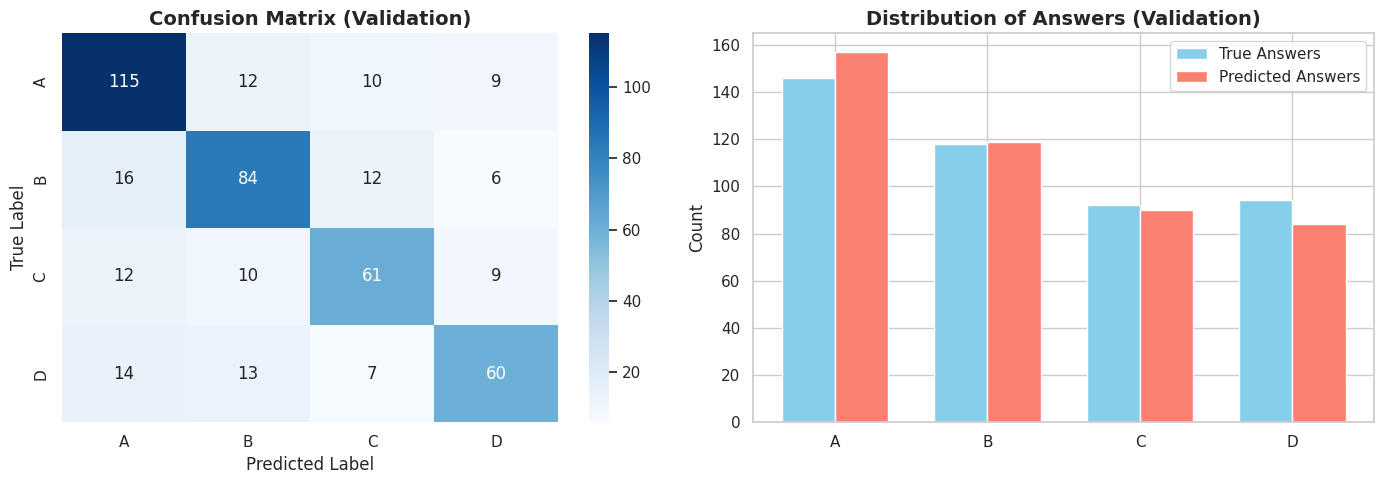

In [35]:
labels_order = ['A', 'B', 'C', 'D']

# 1. 印出詳細的分類報告 (Precision, Recall, F1-Score)
print("📊 Validation Classification Report:")
print("-" * 50)
print(classification_report(true_labels, pred_labels, labels=labels_order, zero_division=0))
print("-" * 50)

# 2. 繪製混淆矩陣 (Confusion Matrix) 熱力圖
cm = confusion_matrix(true_labels, pred_labels, labels=labels_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels_order, yticklabels=labels_order)
axes[0].set_title("Confusion Matrix (Validation)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Predicted Label", fontsize=12)
axes[0].set_ylabel("True Label", fontsize=12)

# 3. 繪製真實答案 vs 預測答案的次數分布長條圖
true_counts = [true_labels.count(l) for l in labels_order]
pred_counts = [pred_labels.count(l) for l in labels_order]

x = np.arange(len(labels_order))
width = 0.35

axes[1].bar(x - width/2, true_counts, width, label='True Answers', color='skyblue')
axes[1].bar(x + width/2, pred_counts, width, label='Predicted Answers', color='salmon')
axes[1].set_title("Distribution of Answers (Validation)", fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_order)
axes[1].set_ylabel("Count", fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

### [Sec 6] Prediction

In [36]:
# # [區塊 7] 測試集預測 - 多數決機制 (Majority Voting: Original, Reversed, Random)

# # 避免不必要的警告訊息打斷進度條
# transformers.logging.set_verbosity_error()

# # 確保開啟 Unsloth 的推論加速模式
# FastLanguageModel.for_inference(model)

# # 1. 讀取測試集資料 (請替換成你真實的測試集檔案名稱，例如 benchmark.csv)
# print(f"📂 正在讀取測試集: {benchmark_path}")
# test_df = pd.read_csv(benchmark_path)


# # 定義一個專門用來產生預測結果的輔助函數
# def get_model_prediction(question, opt_list):
#     prompt = inference_prompt_template.format(
#         question=question,
#         opa=opt_list[0], opb=opt_list[1], opc=opt_list[2], opd=opt_list[3]
#     )
#     inputs = tokenizer([prompt], return_tensors="pt").to("cuda")
#     outputs = model.generate(
#         **inputs,
#         max_new_tokens=5,
#         use_cache=False,       # 避免記憶體形狀報錯
#         pad_token_id=tokenizer.eos_token_id
#     )
#     input_length = inputs["input_ids"].shape[1]
#     generated_tokens = outputs[0][input_length:]
#     output_text = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()
#     match = re.search(r'([ABCD])', output_text.upper())
#     return match.group(1) if match else 'C' # 預設猜 C

# predictions = []
# print("🚀 開始進行測試集多數決預測 (每題推論 3 次)...")

# # 2. 遍歷測試集進行預測
# for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Majority Voting"):
#     q = row['question']
#     # 原本選項的內容與對應的真實索引 (0, 1, 2, 3)
#     orig_opts = [row['opa'], row['opb'], row['opc'], row['opd']]

#     # ---------------------------------------------------------
#     # 🌟 第一輪：原始順序 (Original)
#     # 佈局：A=0, B=1, C=2, D=3
#     idx_map_1 = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
#     ans1_letter = get_model_prediction(q, orig_opts)
#     vote1 = idx_map_1[ans1_letter] # 取得真實的數字答案

#     # ---------------------------------------------------------
#     # 🌟 第二輪：完全反轉 (Reversed)
#     # 佈局：A=3, B=2, C=1, D=0
#     rev_opts = [orig_opts[3], orig_opts[2], orig_opts[1], orig_opts[0]]
#     idx_map_2 = {'A': 3, 'B': 2, 'C': 1, 'D': 0}
#     ans2_letter = get_model_prediction(q, rev_opts)
#     vote2 = idx_map_2[ans2_letter]

#     # ---------------------------------------------------------
#     # 🌟 第三輪：隨機打亂 (Random)
#     # 產生一個 [0, 1, 2, 3] 的隨機排列，例如 [2, 0, 3, 1]
#     rand_indices = [0, 1, 2, 3]
#     random.seed(row.name) # 用 index 當種子確保結果可重現
#     random.shuffle(rand_indices)

#     rand_opts = [orig_opts[i] for i in rand_indices]
#     idx_map_3 = {
#         'A': rand_indices[0], 'B': rand_indices[1],
#         'C': rand_indices[2], 'D': rand_indices[3]
#     }
#     ans3_letter = get_model_prediction(q, rand_opts)
#     vote3 = idx_map_3[ans3_letter]

#     # ---------------------------------------------------------
#     # 📊 計票與決策 (Majority Voting)
#     votes = [vote1, vote2, vote3]
#     vote_counts = Counter(votes)
#     most_common = vote_counts.most_common(1)[0] # 找出得票數最高的

#     # 如果出現平手 (3 個預測都完全不一樣，例如 0, 1, 2)
#     if most_common[1] == 1:
#         # 平手時，最保險的做法是相信「第一輪 (原始順序)」的直覺
#         final_ans = vote1
#     else:
#         # 否則就採納得票數最高 (2 票或 3 票) 的選項
#         final_ans = most_common[0]

#     # final_ans = vote1

#     predictions.append(final_ans)

# # 3. 建立並儲存 Submission 檔案
# submission_df = pd.DataFrame({
#     'question_id': test_df['question_id'], # 請確認 benchmark.csv 是否有這個欄位
#     'ans': predictions
# })


# submission_df.to_csv(submission_path, index=False)

# print(f"\n 多數決預測完成！結果已存檔至: {submission_path}")